In [49]:
# ============================================================
# IMPORT EXPERIMENT MODULE
# ============================================================

from pathlib import Path
import sys
import importlib
import pandas as pd

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.experiments.event_training_comparison as etc
importlib.reload(etc)

<module 'src.experiments.event_training_comparison' from 'C:\\Users\\HUGO\\Desktop\\Q8 - NORUEGA\\TFG\\tfg\\src\\experiments\\event_training_comparison.py'>

In [50]:
# ============================================================
# PATHS
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

rbatheta_base_path = Path(
    r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\rbaTheta\simulations\all_tests_together"
)

def get_rbatheta_events_path(zone_code, year):
    return rbatheta_base_path / f"{zone_code}_{year}_rbatheta_event_hours.csv"

print("DB exists:", db_path.exists())

DB exists: True


In [51]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

zone_code = "NO1"

calibration_start = "2020-01-01"
calibration_end = "2022-12-31"

train_start = "2023-01-01"
train_end = "2023-12-31"

test_start = "2024-04-10"
test_end = "2024-04-16"

target_horizon = 1

rbatheta_train_year = pd.Timestamp(train_start).year

rbatheta_events_path = get_rbatheta_events_path(
    zone_code=zone_code,
    year=rbatheta_train_year,
)

print("Zone:", zone_code)
print("Calibration:", calibration_start, "to", calibration_end)
print("Train:", train_start, "to", train_end)
print("Test:", test_start, "to", test_end)
print("RBA-Theta year:", rbatheta_train_year)
print("RBA-Theta path:", rbatheta_events_path)
print("RBA-Theta exists:", rbatheta_events_path.exists())

Zone: NO1
Calibration: 2020-01-01 to 2022-12-31
Train: 2023-01-01 to 2023-12-31
Test: 2024-04-10 to 2024-04-16
RBA-Theta year: 2023
RBA-Theta path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\rbaTheta\simulations\all_tests_together\NO1_2023_rbatheta_event_hours.csv
RBA-Theta exists: True


In [52]:
# ============================================================
# LOAD CALIBRATION + TRAIN + TEST DATA
# ============================================================

importlib.reload(etc)

df_prices_test = etc.load_calibration_train_test_prices(
    db_path=db_path,
    zone_code=zone_code,

    calibration_start=calibration_start,
    calibration_end=calibration_end,

    train_start=train_start,
    train_end=train_end,

    test_start=test_start,
    test_end=test_end,
)

print("Shape:", df_prices_test.shape)
print("Start:", df_prices_test["delivery_day"].min())
print("End:", df_prices_test["delivery_day"].max())

df_prices_test.head()

Shape: (35232, 6)
Start: 2020-01-01
End: 2024-04-16


,price_id,zone_id,zone_code,delivery_day,hour,price_value
0,12,12,NO1,2020-01-01,0,31.82
1,32,12,NO1,2020-01-01,1,31.77
2,52,12,NO1,2020-01-01,2,31.57
3,72,12,NO1,2020-01-01,3,31.28
4,92,12,NO1,2020-01-01,4,30.72


In [53]:
# ============================================================
# PREPARE AND SPLIT DATA
# ============================================================

df_model_test = etc.prepare_model_dataset(
    df_prices=df_prices_test,
    target_horizon=target_horizon,
)

df_calibration, df_train_full, df_test_common = etc.split_calibration_train_test_periods(
    df_model=df_model_test,

    calibration_start=calibration_start,
    calibration_end=calibration_end,

    train_start=train_start,
    train_end=train_end,

    test_start=test_start,
    test_end=test_end,
)

print("Calibration:", df_calibration.shape)
print("Train:", df_train_full.shape)
print("Test:", df_test_common.shape)

print("Calibration period:", df_calibration["datetime"].min(), "to", df_calibration["datetime"].max())
print("Train period:", df_train_full["datetime"].min(), "to", df_train_full["datetime"].max())
print("Test period:", df_test_common["datetime"].min(), "to", df_test_common["datetime"].max())

Calibration: (26304, 11)
Train: (8759, 11)
Test: (167, 11)
Calibration period: 2020-01-01 00:00:00 to 2022-12-31 23:00:00
Train period: 2023-01-01 00:00:00 to 2023-12-31 22:00:00
Test period: 2024-04-10 00:00:00 to 2024-04-16 22:00:00


In [43]:
# ============================================================
# CALIBRATE EVENT THRESHOLDS
# ============================================================

thresholds_calibration = etc.calibrate_price_event_thresholds(
    df_calibration=df_calibration
)

thresholds_calibration

{'low_price': np.float64(2.97),
 'high_price': np.float64(204.984),
 'extreme_price': np.float64(290.08049999999986),
 'price_spike': np.float64(5.030000000000001),
 'rapid_price_change': np.float64(22.31799999999995),
 'price_ramp_up': np.float64(11.788999999999946),
 'price_ramp_down': np.float64(-11.660000000000025),
 'high_volatility': np.float64(36.47943725500736)}

In [54]:
# ============================================================
# APPLY FROZEN EVENTS TO TRAIN DATA
# ============================================================

df_train_events, own_event_cols = etc.apply_calibrated_price_events(
    df=df_train_full,
    thresholds=thresholds_calibration,
)

print("Train full:", df_train_full.shape)

print("\nEvent counts:")
print(df_train_events[own_event_cols].sum().sort_values(ascending=False))

print("\nTotal own event hours:")
print(df_train_events["own_event"].sum())

print("\nTrain data used (%):")
print(df_train_events["own_event"].sum() / len(df_train_events) * 100)

Train full: (8759, 11)

Event counts:
price_spike           1063
low_price              896
price_ramp_up          384
price_ramp_down        336
high_volatility        302
rapid_price_change     249
high_price              46
extreme_price            1
dtype: int64

Total own event hours:
2454

Train data used (%):
28.016896906039502


In [55]:
# ============================================================
# BUILD FINAL TRAINING DATASETS
# ============================================================

# 1. Full training dataset
df_train_full_final = df_train_full.copy()

# 2. rbaTheta training dataset
df_train_rbatheta = etc.build_rbatheta_train_dataset(
    df_train_full=df_train_full,
    rbatheta_events_path=rbatheta_events_path,
)

# 3. Own calibrated event training dataset
df_train_own = df_train_events[
    df_train_events["own_event"]
].copy()

train_datasets = {
    "full_prices": df_train_full_final,
    "rbatheta_events": df_train_rbatheta,
    "own_events": df_train_own,
}

print("Full prices:", len(df_train_full_final))
print("rbaTheta events:", len(df_train_rbatheta))
print("Own events:", len(df_train_own))

print("\nTrain data used (%):")
for name, dataset in train_datasets.items():
    print(name, round(len(dataset) / len(df_train_full_final) * 100, 2))

Full prices: 8759
rbaTheta events: 4771
Own events: 2454

Train data used (%):
full_prices 100.0
rbatheta_events 54.47
own_events 28.02


In [56]:
# ============================================================
# TRAIN MODELS WITH FINAL TRAINING DATASETS
# ============================================================

models = etc.get_default_models()

feature_cols = [
    "price_value",
    "hour_of_day",
    "day_of_week",
    "month",
]

target_col = "target_price_1h"

all_results = []
all_predictions = {}

for model_name, model_factory in models.items():
    model_results, model_predictions = etc.train_single_model_with_training_sets(
        model_name=model_name,
        model_factory=model_factory,
        train_datasets=train_datasets,
        df_test=df_test_common,
        feature_cols=feature_cols,
        target_col=target_col,
        full_train_size=len(df_train_full_final),
    )

    all_results.extend(model_results)
    all_predictions[model_name] = model_predictions

results_table = etc.build_results_table(all_results)

results_table["Zone"] = zone_code
results_table["Calibration period"] = f"{calibration_start} to {calibration_end}"
results_table["Train period"] = f"{train_start} to {train_end}"
results_table["Test period"] = f"{test_start} to {test_end}"

ordered_cols = [
    "Zone",
    "Calibration period",
    "Train period",
    "Test period",
    "Model",
    "Training dataset",
    "Training samples",
    "Test samples",
    "Train data used (%)",
    "Data reduction (%)",
    "RMSE",
    "RMSLE",
]

results_table = results_table[ordered_cols]

results_table

,Zone,Calibration period,Train period,Test period,Model,Training dataset,Training samples,Test samples,Train data used (%),Data reduction (%),RMSE,RMSLE
0,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,Linear Regression,full_prices,8759,167,100.00,0.00,10.6279,0.5678
1,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,Linear Regression,rbatheta_events,4771,167,54.47,45.53,10.6546,0.5692
2,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,Linear Regression,own_events,2454,167,28.02,71.98,11.0279,0.6149
3,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,Decision Tree,full_prices,8759,167,100.00,0.00,22.7710,0.9897
4,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,Decision Tree,rbatheta_events,4771,167,54.47,45.53,20.1837,0.8952
5,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,Decision Tree,own_events,2454,167,28.02,71.98,24.1504,0.9743
6,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,Random Forest,full_prices,8759,167,100.00,0.00,11.6661,0.6140
7,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,Random Forest,rbatheta_events,4771,167,54.47,45.53,11.7484,0.6381
8,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,Random Forest,own_events,2454,167,28.02,71.98,13.0023,0.6788
9,NO1,2020-01-01 to 2022-12-31,2023-01-01 to 2023-12-31,2024-04-10 to 2024-04-16,XGBoost,full_prices,8759,167,100.00,0.00,10.7350,0.6330


In [57]:
# ============================================================
# SAVE EXPERIMENT RESULTS
# ============================================================

from pathlib import Path
import json
import shutil

# ----------------------------
# 1. Define experiment folder
# ----------------------------

def clean_date(date_str):
    return date_str.replace("-", "")

experiment_name = (
    f"{zone_code}_"
    f"cal{clean_date(calibration_start)}-{clean_date(calibration_end)}_"
    f"train{clean_date(train_start)}-{clean_date(train_end)}_"
    f"test{clean_date(test_start)}-{clean_date(test_end)}"
)

results_dir = (
    project_root
    / "results"
    / "event_training_comparison"
    / experiment_name
)

predictions_dir = results_dir / "predictions"
plots_dir = results_dir / "plots"

results_dir.mkdir(parents=True, exist_ok=True)

if predictions_dir.exists():
    shutil.rmtree(predictions_dir)

if plots_dir.exists():
    shutil.rmtree(plots_dir)

predictions_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

print("Saving experiment in:")
print(results_dir)

# ----------------------------
# 2. Save results table
# ----------------------------

results_table.to_csv(
    results_dir / "results_table.csv",
    index=False
)

results_table.to_excel(
    results_dir / "results_table.xlsx",
    index=False
)

# ----------------------------
# 3. Save predictions
# ----------------------------

for model_name, model_predictions in all_predictions.items():
    for dataset_name, pred_df in model_predictions.items():

        safe_model_name = model_name.replace(" ", "_").replace("/", "_")
        safe_dataset_name = dataset_name.replace(" ", "_").replace("/", "_")

        pred_path = predictions_dir / f"{safe_model_name}_{safe_dataset_name}_predictions.csv"

        pred_df.to_csv(pred_path, index=False)

# ----------------------------
# 4. Save experiment metadata
# ----------------------------

metadata = {
    "zone_code": zone_code,

    "calibration_period": {
        "start": calibration_start,
        "end": calibration_end,
    },

    "train_period": {
        "start": train_start,
        "end": train_end,
    },

    "test_period": {
        "start": test_start,
        "end": test_end,
    },

    "target": {
        "target_col": target_col,
        "target_horizon_hours": target_horizon,
    },

    "features": feature_cols,

    "training_datasets": {
        dataset_name: {
            "samples": len(dataset),
            "train_data_used_pct": round(
                len(dataset) / len(df_train_full_final) * 100,
                2
            ),
            "data_reduction_pct": round(
                100 - (len(dataset) / len(df_train_full_final) * 100),
                2
            ),
        }
        for dataset_name, dataset in train_datasets.items()
    },

    "own_events": {
        "event_columns": own_event_cols,
        "thresholds": {
            key: float(value)
            for key, value in thresholds_calibration.items()
        },
        "total_event_hours": int(len(df_train_own)),
        "train_data_used_pct": round(
            len(df_train_own) / len(df_train_full_final) * 100,
            2
        ),
    },

    "rbatheta": {
        "events_path": str(rbatheta_events_path),
        "train_year": int(rbatheta_train_year),
        "total_event_hours": int(len(df_train_rbatheta)),
        "train_data_used_pct": round(
            len(df_train_rbatheta) / len(df_train_full_final) * 100,
            2
        ),
    },

    "models": list(models.keys()),

    "output_files": {
        "results_table_csv": "results_table.csv",
        "results_table_excel": "results_table.xlsx",
        "metadata": "metadata.json",
        "predictions_folder": "predictions/",
        "plots_folder": "plots/",
    },
}

with open(results_dir / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Saved:")
print("- results_table.csv")
print("- results_table.xlsx")
print("- metadata.json")
print("- predictions/*.csv")
print("- plots/")

Saving experiment in:
C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_test20240410-20240416
Saved:
- results_table.csv
- results_table.xlsx
- metadata.json
- predictions/*.csv
- plots/


Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_test20240410-20240416\plots\Linear_Regression_RMSE_vs_training_samples.png


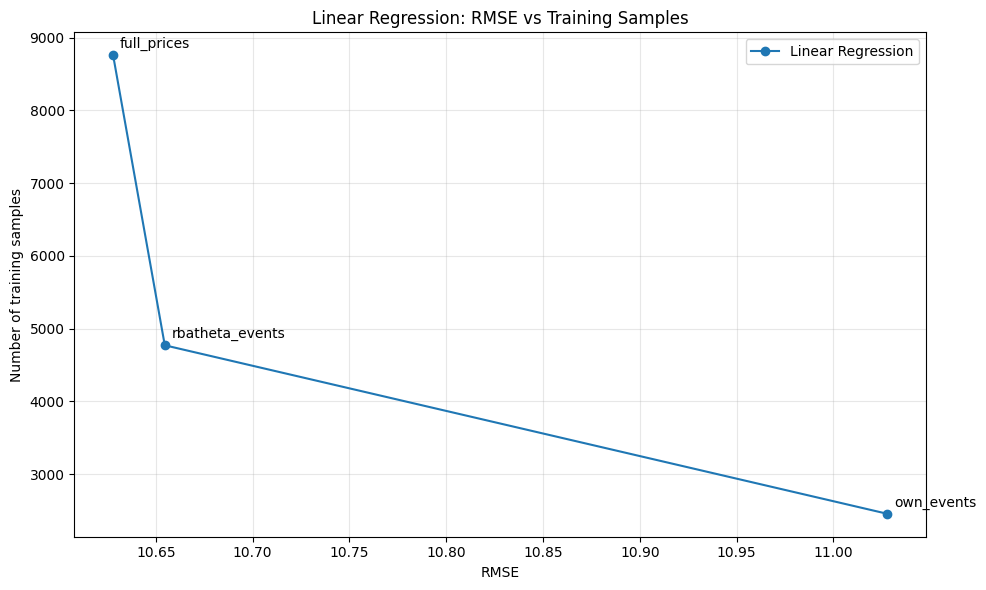

Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_test20240410-20240416\plots\Decision_Tree_RMSE_vs_training_samples.png


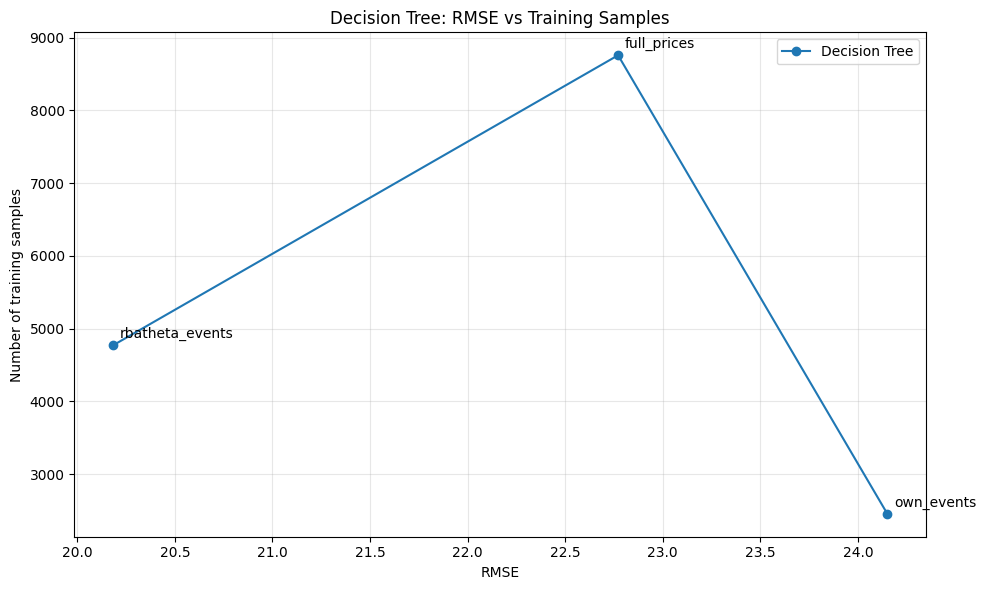

Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_test20240410-20240416\plots\Random_Forest_RMSE_vs_training_samples.png


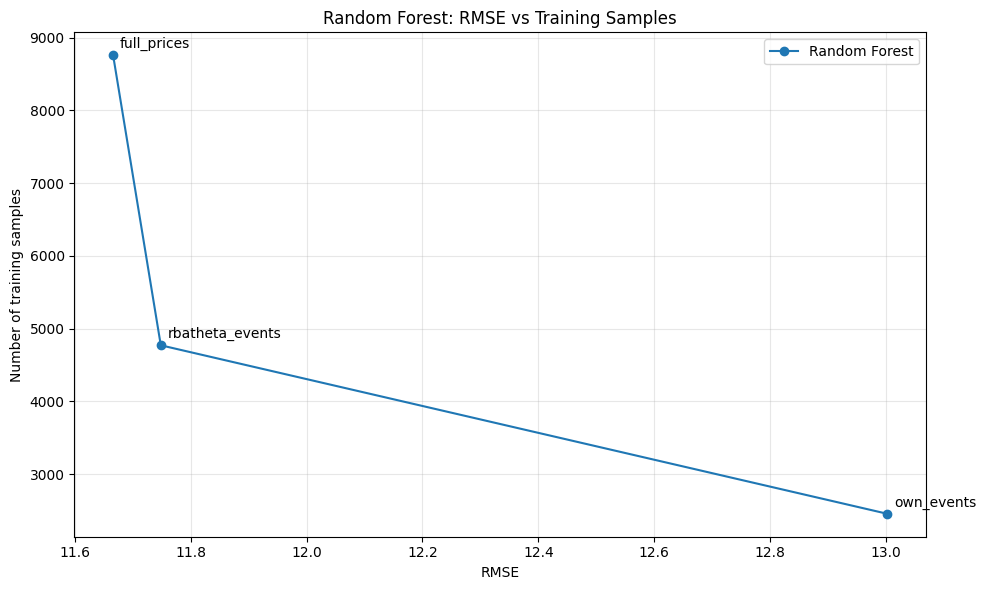

Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_test20240410-20240416\plots\XGBoost_RMSE_vs_training_samples.png


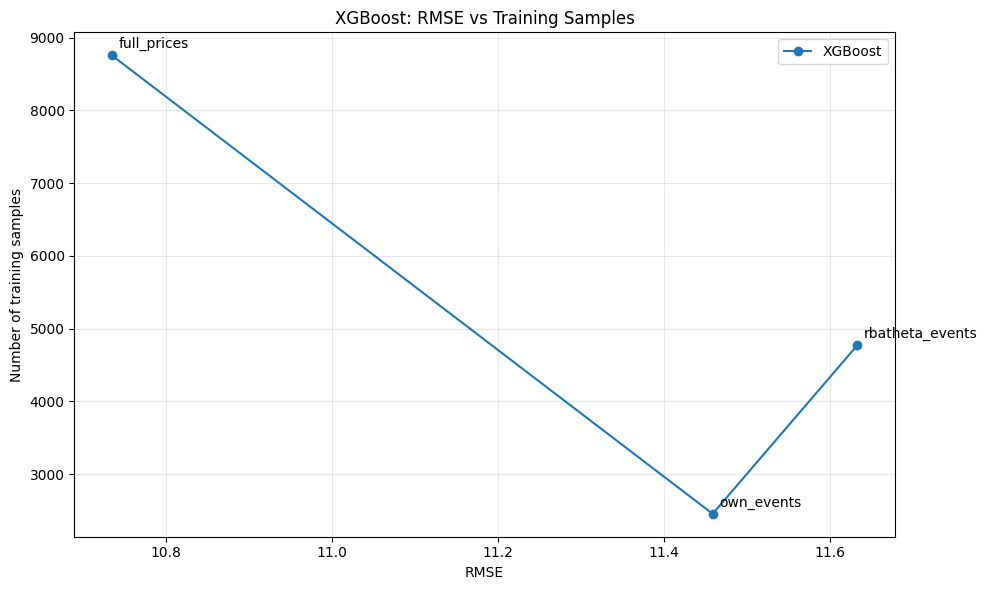

Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_test20240410-20240416\plots\Linear_Regression_RMSLE_vs_training_samples.png


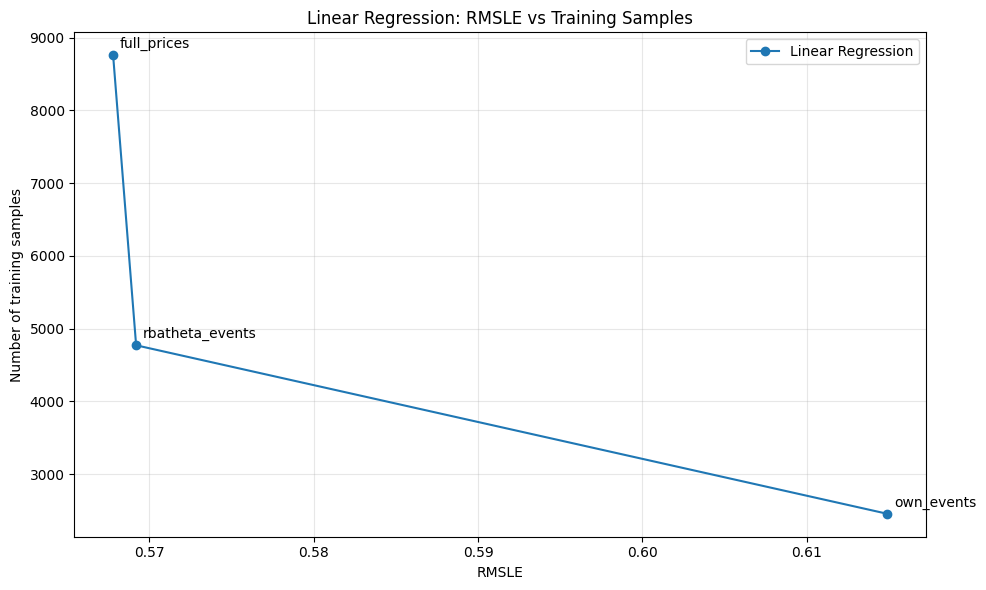

Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_test20240410-20240416\plots\Decision_Tree_RMSLE_vs_training_samples.png


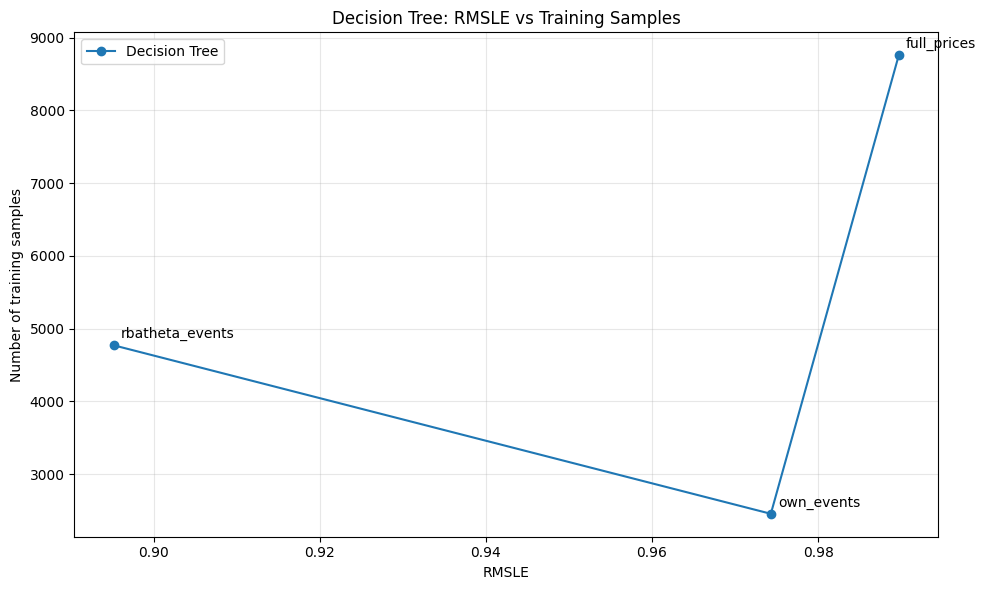

Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_test20240410-20240416\plots\Random_Forest_RMSLE_vs_training_samples.png


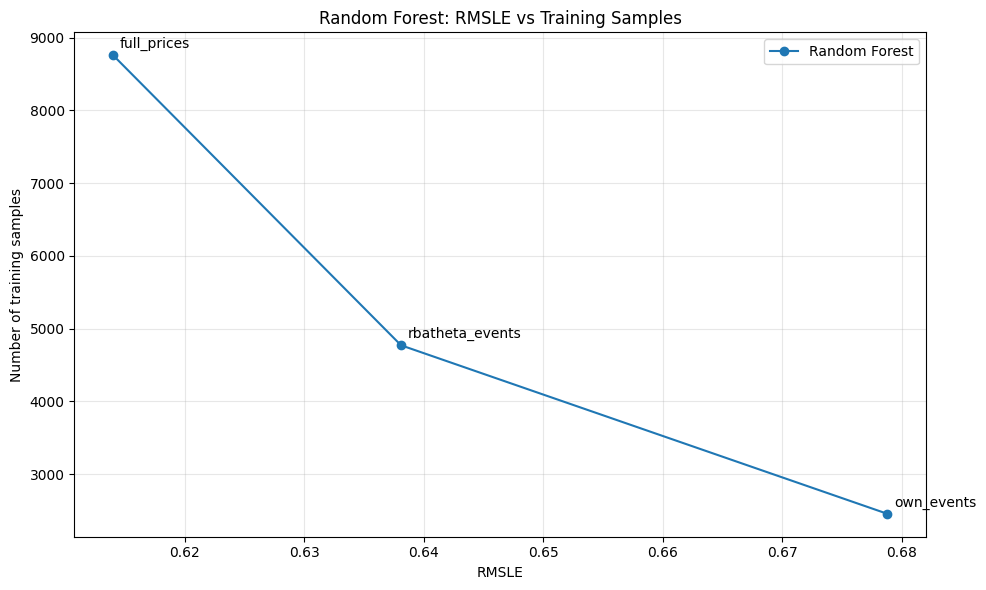

Saved: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_test20240410-20240416\plots\XGBoost_RMSLE_vs_training_samples.png


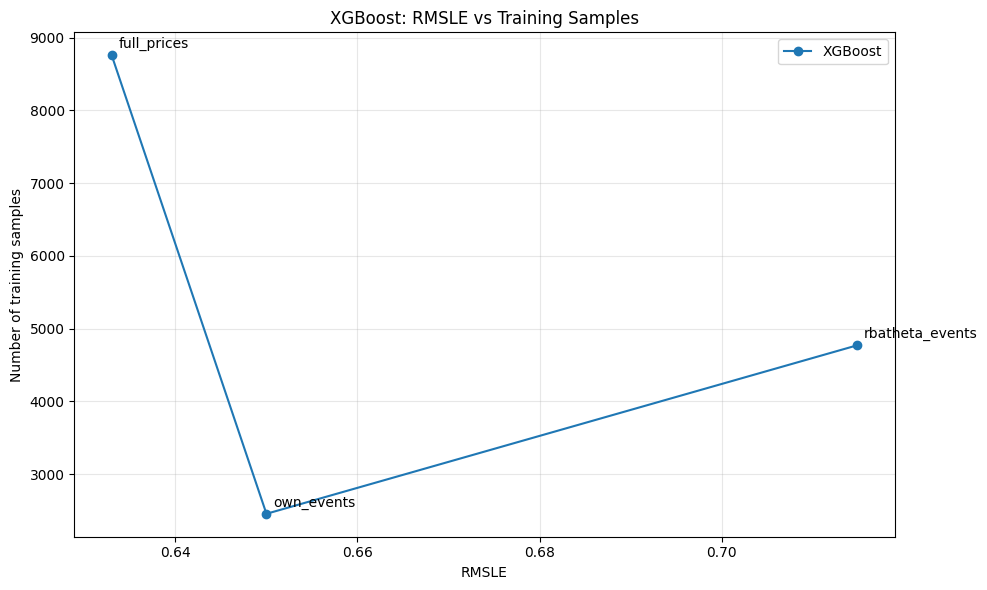

In [58]:
# ============================================================
# PLOTS BY MODEL - SEPARATED AND SAVED
# ============================================================

etc.plot_metric_vs_training_samples_by_model(
    results_table=results_table,
    metric="RMSE",
    save_dir=plots_dir
)

etc.plot_metric_vs_training_samples_by_model(
    results_table=results_table,
    metric="RMSLE",
    save_dir=plots_dir
)